In [103]:
import torch
import torch
from collections import deque
import torch.nn.functional as F
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
from matplotlib import pyplot as plt
from sklearn.inspection import permutation_importance
import numpy as np

In [84]:
data=torch.load("./../train_data_with_context/all_conversations.pt")
data2=torch.load("./../train_data_with_context/all_conversations2.pt")

In [85]:
labels_map={
    1:0,
    2:0,
    3:0,
    4:1,
    5:1
}

In [86]:
def feature_engineering(x_t,u_t,x_prev,u_prev,x_prev_4step_back=None,u_prev_4step_back=None,):
    features = []

    state_drift = torch.norm(x_t - x_prev).item()
    features.append(state_drift)

    input_embedding_drift = torch.norm(u_t - u_prev).item()
    features.append(input_embedding_drift)

    state_input_distance = torch.norm(x_t - u_t).item()
    features.append(state_input_distance)

    state_similarity = F.cosine_similarity(x_t.unsqueeze(0), x_prev.unsqueeze(0)).item()
    features.append(state_similarity)

    input_embedding_similarity = F.cosine_similarity(u_t.unsqueeze(0),u_prev.unsqueeze(0)
    ).item()
    features.append(input_embedding_similarity)

    state_input_similarity = F.cosine_similarity(
        x_t.unsqueeze(0),
        u_t.unsqueeze(0)
    ).item()
    features.append(state_input_similarity)

    long_term_state_drift = torch.norm(
        x_t - x_prev_4step_back
    ).item()
    features.append(long_term_state_drift)

    long_term_state_similarity = F.cosine_similarity(
        x_t.unsqueeze(0),
        x_prev_4step_back.unsqueeze(0)
    ).item()
    features.append(long_term_state_similarity)

    long_term_embedding_drift = torch.norm(
        u_t - u_prev_4step_back
    ).item()
    features.append(long_term_embedding_drift)

    long_term_embedding_similarity = F.cosine_similarity(
        u_t.unsqueeze(0),
        u_prev_4step_back.unsqueeze(0)
    ).item()
    features.append(long_term_embedding_similarity)

    return torch.tensor(features, dtype=torch.float32)

In [87]:
X2_vecs = []
X2_features = []
y2 = []

for convo in data2:
    first_x = convo[0]["x_t"]
    first_u = convo[0]["ut"]

    x_prev = torch.zeros_like(convo[0]["x_t"])
    u_prev = torch.zeros_like(convo[0]["ut"])

    x_history = deque(maxlen=4)
    u_history = deque(maxlen=4)

    for turn in convo:
        X2_vecs.append(torch.concat([turn["x_t"], turn["ut"]], dim=0))

        if len(x_history) == 4:
            x_prev_4step_back = x_history[0]
            u_prev_4step_back = u_history[0]
        else:
            x_prev_4step_back = first_x
            u_prev_4step_back = first_u

        handcrafted = feature_engineering(
            turn["x_t"],
            turn["ut"],
            x_prev,
            u_prev,
            x_prev_4step_back,
            u_prev_4step_back
        ).numpy()

        X2_features.append(handcrafted)
        y2.append(labels_map[turn["score"]])

        x_history.append(turn["x_t"])
        u_history.append(turn["ut"])

        x_prev = turn["x_t"]
        u_prev = turn["ut"]

In [88]:
feature_names = [
    "state_drift",
    "input_embedding_drift",
    "state_input_distance",
    "state_similarity",
    "input_embedding_similarity",
    "state_input_similarity",
    "long_term_state_drift",
    "long_term_state_similarity",
    "long_term_embedding_drift",
    "long_term_embedding_similarity"
]

In [89]:
df = pd.DataFrame(X2_features, columns=feature_names)
df["label"] = y2

In [90]:
unique_labels = sorted(df["label"].unique())

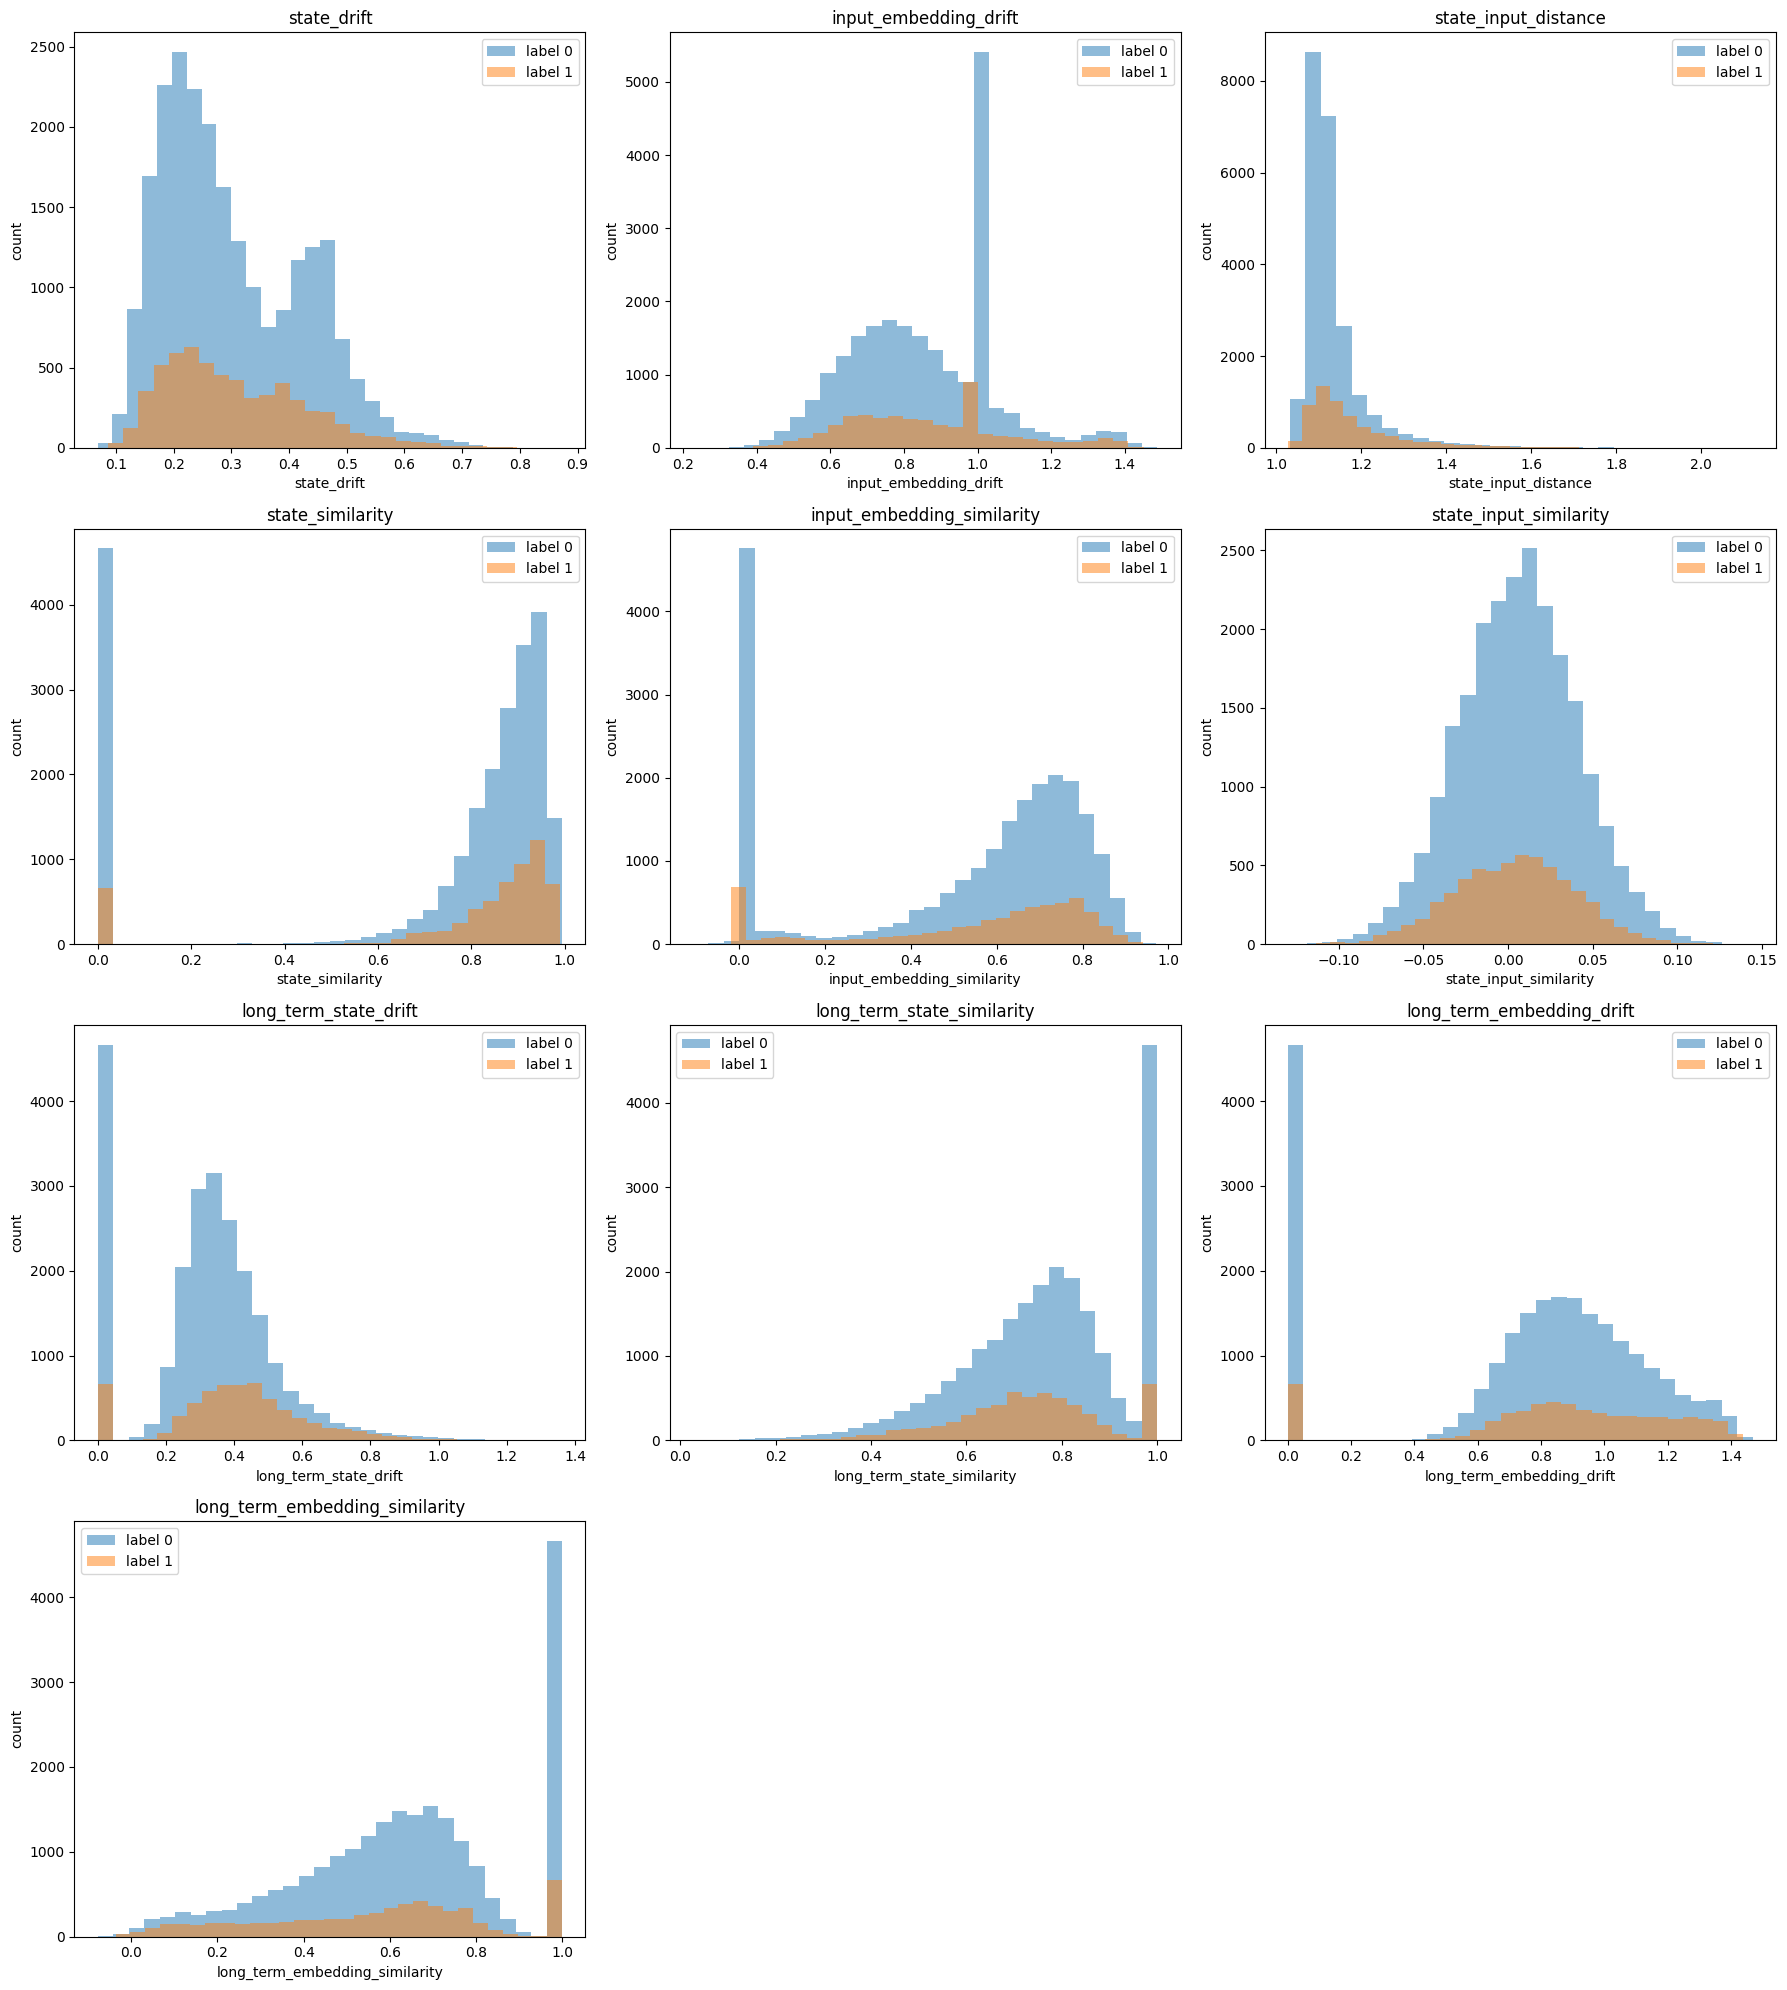

In [91]:
n_cols = 3
n_rows = int(np.ceil(len(feature_names) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 5 * n_rows))
axes = axes.flatten()

for i, feature in enumerate(feature_names):
    ax = axes[i]

    for lbl in unique_labels:
        subset = df[df["label"] == lbl][feature]
        ax.hist(subset, bins=30, alpha=0.5, label=f"label {lbl}")

    ax.set_title(feature)
    ax.set_xlabel(feature)
    ax.set_ylabel("count")
    ax.legend()

# remove empty subplots (if any)
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [92]:
all_features = {}

for f in feature_names:
    x = df[f].copy()
    all_features[f"{f}_orig"] = x
    all_features[f"{f}_log"] = np.log1p(df[feature])
    all_features[f"{f}_sqrt"] = np.sqrt(df[feature])
    if "similarity" in f:
        x += 1+ 1e-6  
    else:
        x+=1e-6  
    if (x > 0).all():
        all_features[f"{f}_boxcox"], _ = stats.boxcox(x)

d:\anaconda\envs\genai-env\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: invalid value encountered in sqrt
  result = getattr(ufunc, method)(*inputs, **kwargs)


In [93]:
df_trans = pd.DataFrame(all_features)
df_trans["label"] = df["label"]

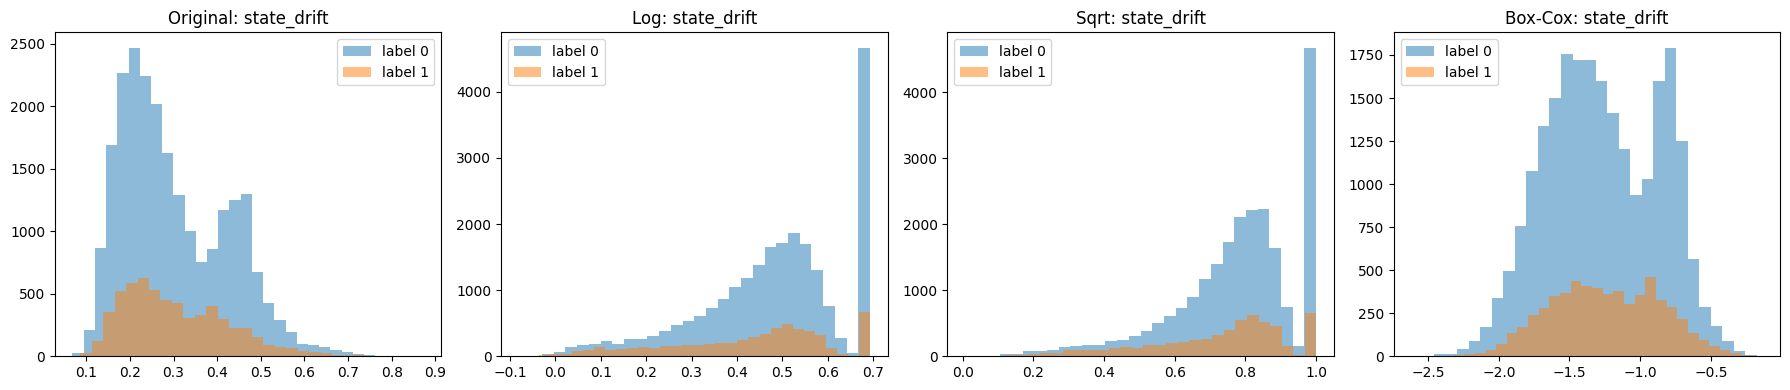

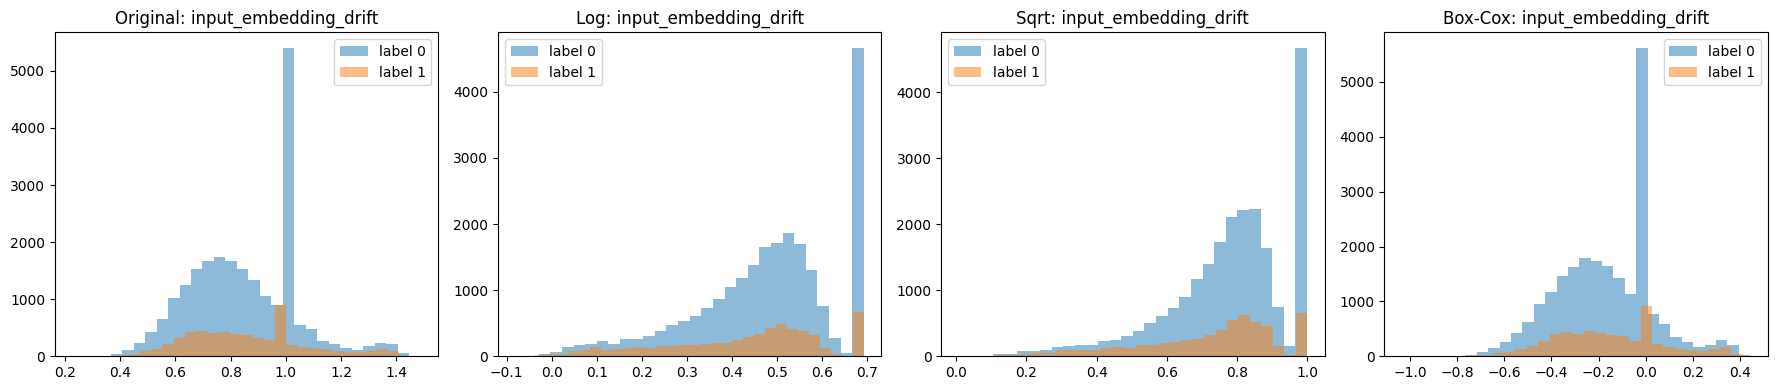

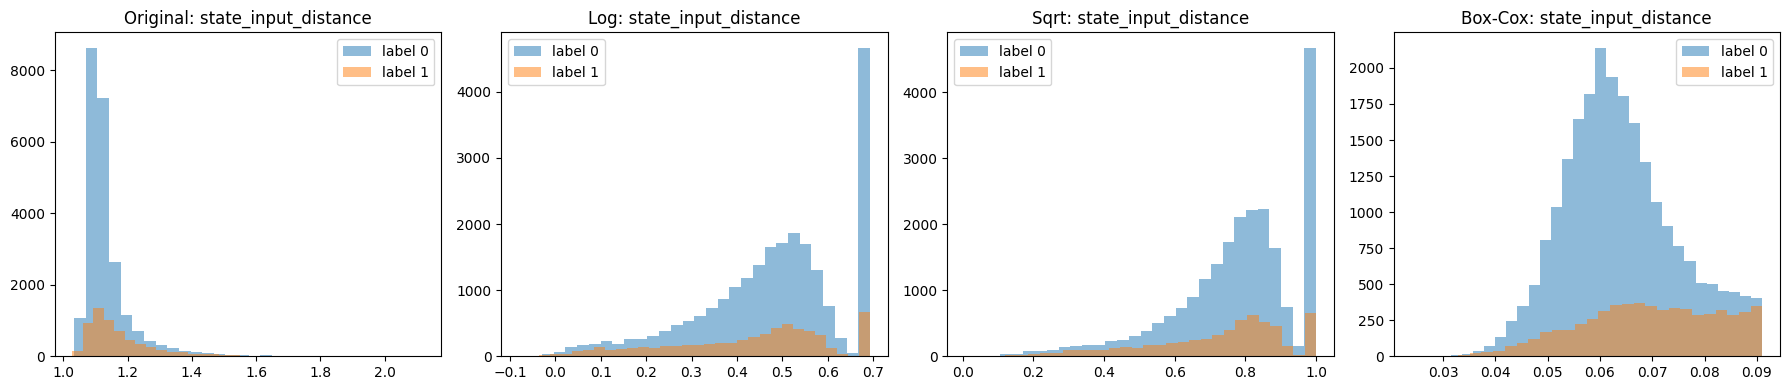

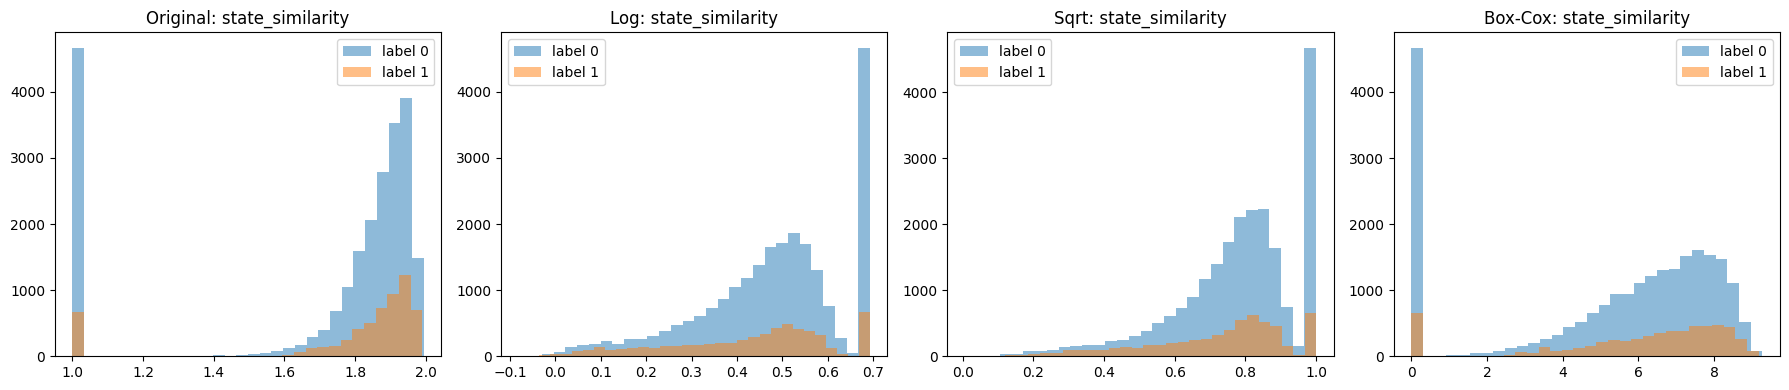

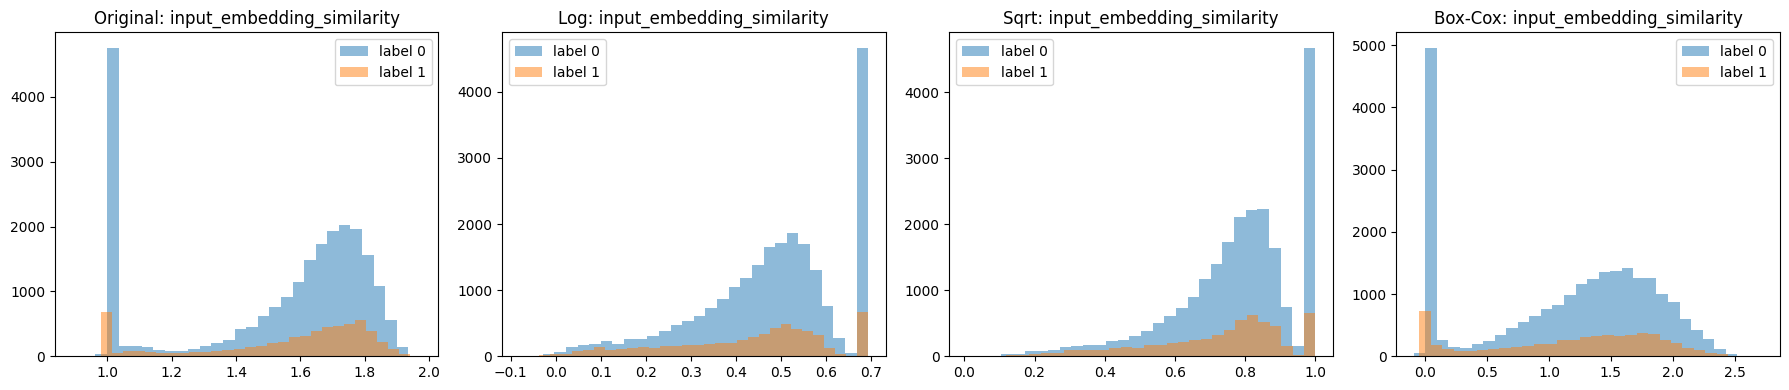

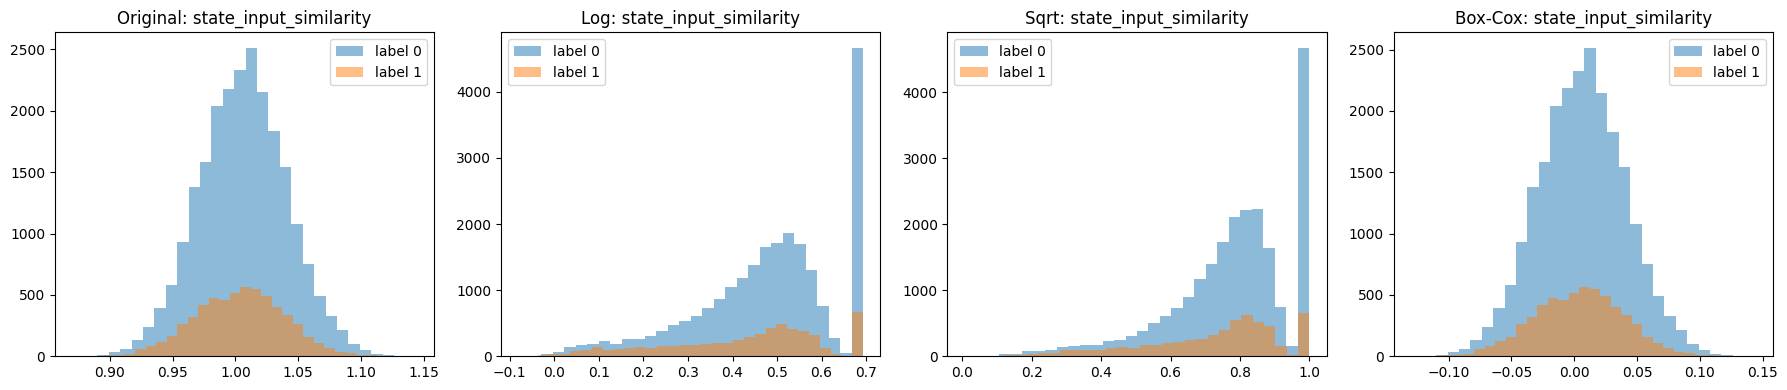

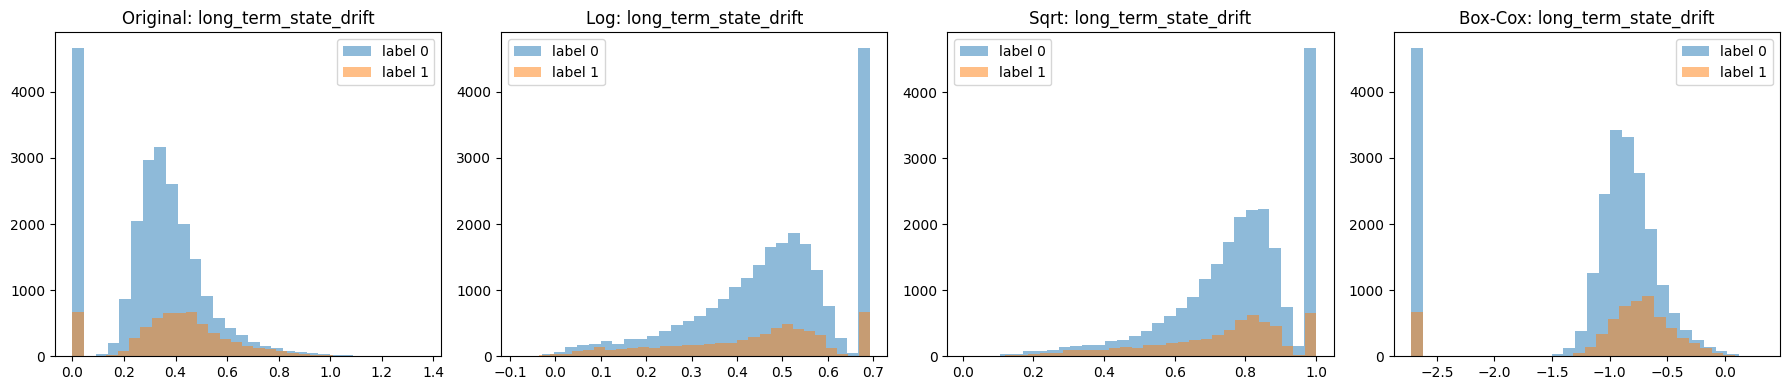

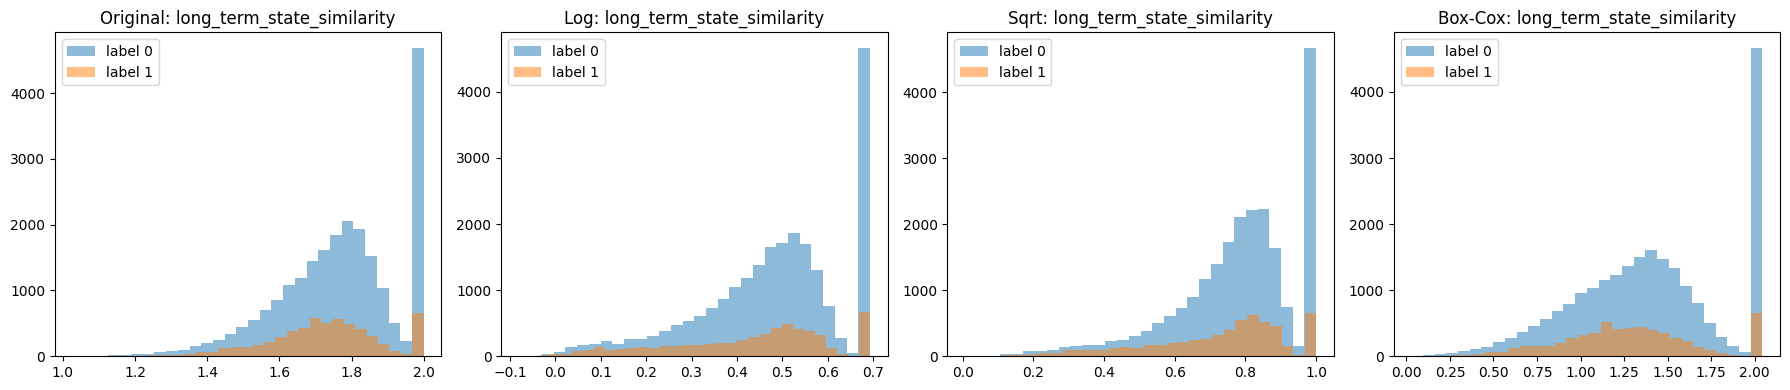

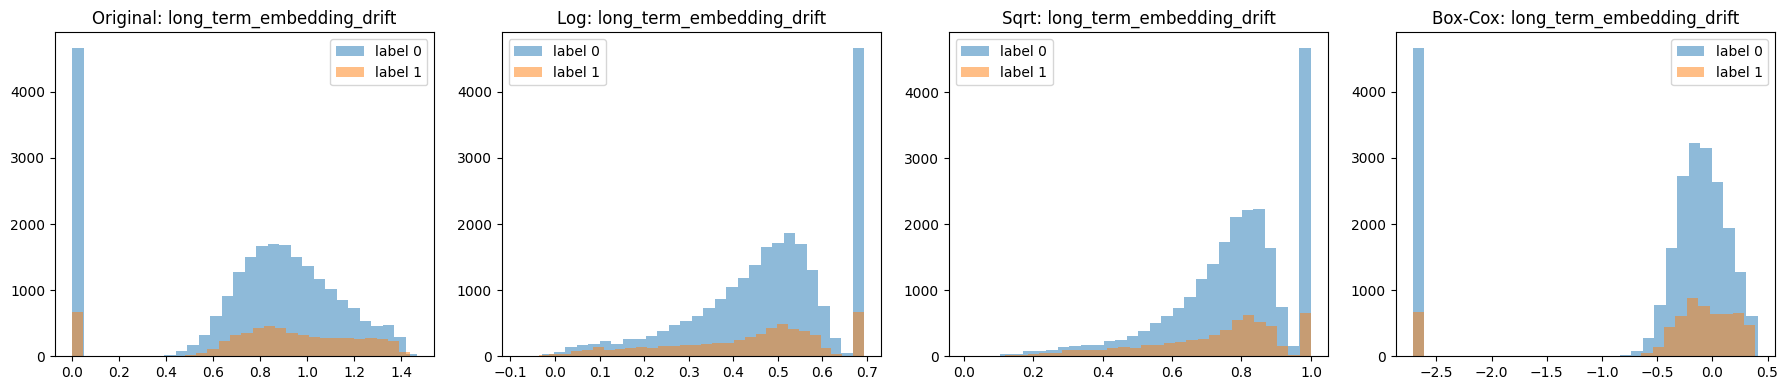

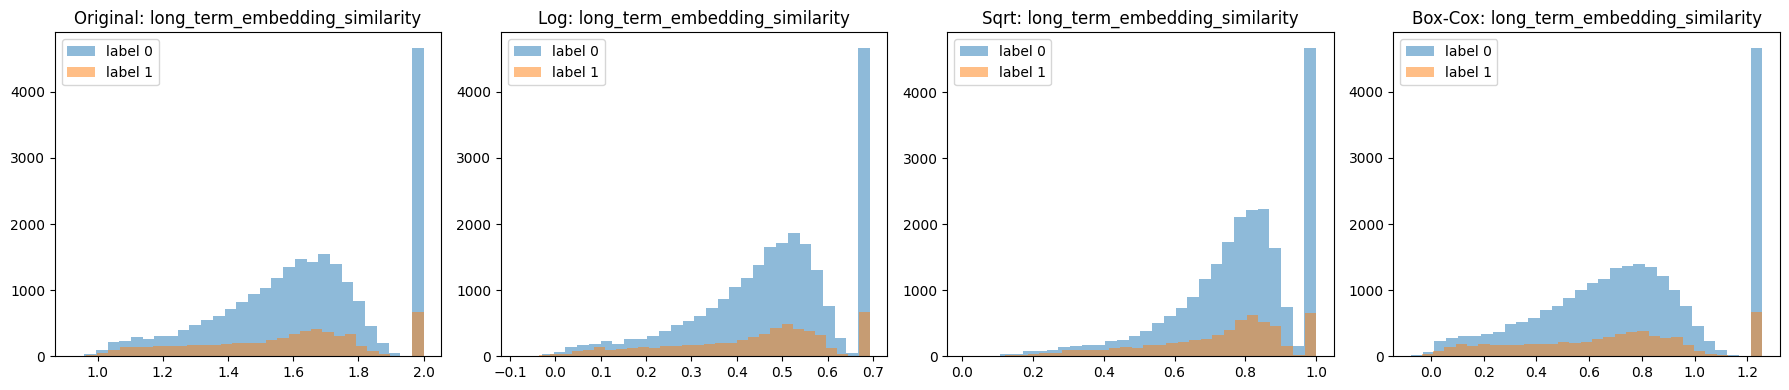

In [94]:
for feature in feature_names:
    fig, axes = plt.subplots(1, 4, figsize=(18, 4))

    for lbl in df_trans["label"].unique():
        subset = df_trans[df_trans["label"] == lbl][feature+"_orig"]
        axes[0].hist(subset, bins=30, alpha=0.5, label=f"label {lbl}")
        subset_log = df_trans[df_trans["label"] == lbl][f"{feature}_log"]
        axes[1].hist(subset_log, bins=30, alpha=0.5, label=f"label {lbl}")
        subset_sqrt = df_trans[df_trans["label"] == lbl][f"{feature}_sqrt"]
        axes[2].hist(subset_sqrt, bins=30, alpha=0.5, label=f"label {lbl}")
        subset_boxcox = df_trans[df_trans["label"] == lbl][f"{feature}_boxcox"]
        axes[3].hist(subset_boxcox, bins=30, alpha=0.5, label=f"label {lbl}")

    axes[0].set_title(f"Original: {feature}")
    axes[1].set_title(f"Log: {feature}")
    axes[2].set_title(f"Sqrt: {feature}")
    axes[3].set_title(f"Box-Cox: {feature}")

    for ax in axes:
        ax.legend()

    plt.tight_layout()
    plt.show()

In [95]:
df_trans = pd.DataFrame(all_features)
df_trans["label"] = df["label"]

In [96]:
corr_with_label = df_trans.corr(method="spearman")["label"].drop("label")

In [97]:
best_features = []

for f in feature_names:
    candidates = {
        "orig": corr_with_label.get(f"{f}_orig", 0),
        "log": corr_with_label.get(f"{f}_log", 0),
        "sqrt": corr_with_label.get(f"{f}_sqrt", 0),
        "boxcox": corr_with_label.get(f"{f}_boxcox", 0),
    }

    best_variant = max(candidates, key=lambda k: abs(candidates[k]))
    best_features.append(f"{f}_{best_variant}")

In [98]:
best_features

['state_drift_log',
 'input_embedding_drift_log',
 'state_input_distance_orig',
 'state_similarity_log',
 'input_embedding_similarity_log',
 'state_input_similarity_log',
 'long_term_state_drift_orig',
 'long_term_state_similarity_log',
 'long_term_embedding_drift_orig',
 'long_term_embedding_similarity_orig']

In [101]:
from sklearn.ensemble import RandomForestClassifier

X = df_trans[best_features]
y = df_trans["label"]

model = RandomForestClassifier(n_estimators=200, random_state=42)
model.fit(X, y)

importances = model.feature_importances_

feature_importance = sorted(
    zip(X.columns, importances),
    key=lambda x: x[1],
    reverse=True
)

for f, imp in feature_importance:
    print(f"{f}: {imp:.4f}")

state_input_distance_orig: 0.2328
long_term_state_drift_orig: 0.1735
long_term_embedding_similarity_orig: 0.0749
long_term_state_similarity_log: 0.0744
state_input_similarity_log: 0.0744
input_embedding_drift_log: 0.0742
state_similarity_log: 0.0742
input_embedding_similarity_log: 0.0740
long_term_embedding_drift_orig: 0.0740
state_drift_log: 0.0736


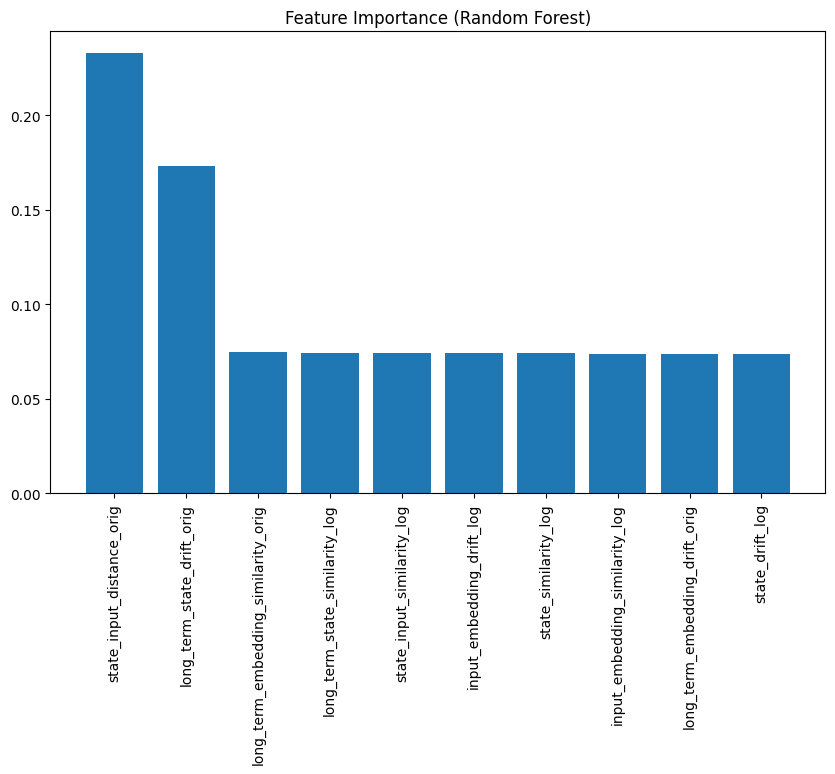

In [ ]:
names = [f for f, _ in feature_importance]
values = [imp for _, imp in feature_importance]

plt.figure(figsize=(10, 6))
plt.bar(names, values)
plt.xticks(rotation=90)
plt.title("Feature Importance (Random Forest)")
plt.show()

In [104]:
result = permutation_importance(
    model, X, y,
    n_repeats=10,
    random_state=42
)

In [106]:
importances = pd.DataFrame({
    "feature": X.columns,
    "importance": result.importances_mean,
    "std": result.importances_std
})

importances = importances.sort_values("importance", ascending=False)
print(importances)

                               feature  importance       std
2            state_input_distance_orig    0.171510  0.001132
6           long_term_state_drift_orig    0.161645  0.001114
9  long_term_embedding_similarity_orig    0.007481  0.000375
4       input_embedding_similarity_log    0.001612  0.000173
7       long_term_state_similarity_log    0.001270  0.000199
3                 state_similarity_log    0.000766  0.000087
1            input_embedding_drift_log    0.000763  0.000102
0                      state_drift_log   -0.000386  0.000154
8       long_term_embedding_drift_orig   -0.000514  0.000207
5           state_input_similarity_log   -0.001090  0.000235


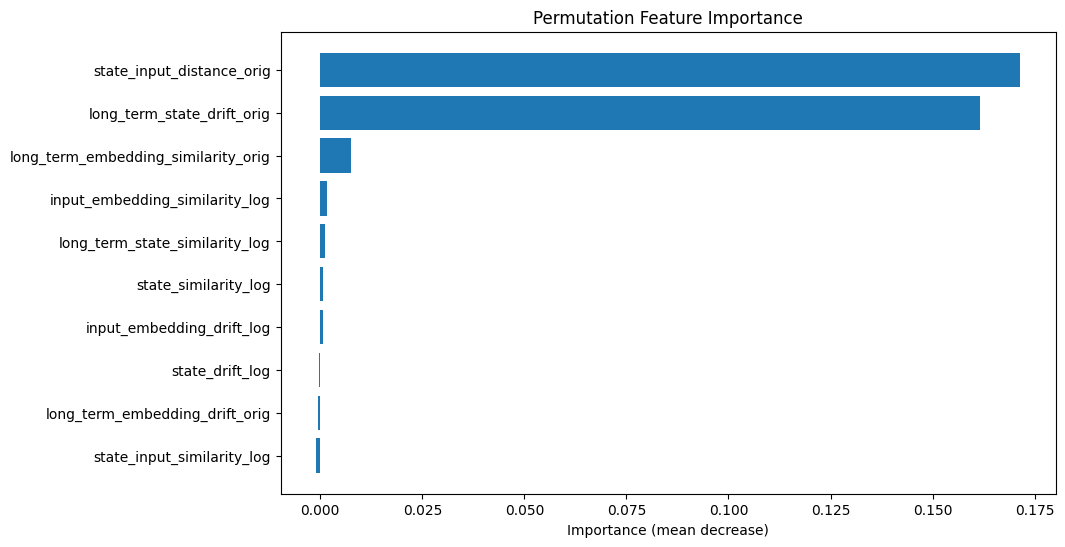

In [107]:
plt.figure(figsize=(10, 6))
plt.barh(importances["feature"], importances["importance"])
plt.gca().invert_yaxis()
plt.title("Permutation Feature Importance")
plt.xlabel("Importance (mean decrease)")
plt.show()